In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#Used my own file path because I wanted to just do it in VSC
df = pd.read_csv(r"...", encoding='utf-8')
df.head()

,case_id,snapshot_at,created_at,channel,case_type,category,subcategory,priority,sla_target_hours,first_response_time_hours,...,escalation_team,customer_tenure_months,plan_tier,region_uk,age_band,gender,case_summary,sentiment,csat_score,tags
0,ND-2025-000400,2026-01-01T00:00:00Z,2025-03-01T08:15:22Z,email,service_request,billing_payments,vat_receipt,Medium,24,2.5,...,NaN,12,Pro,London,35-44,F,Need a VAT receipt for the last Orbit ID subsc...,Neutral,5,vat;subscription;invoice
1,ND-2025-000401,2026-01-01T00:00:00Z,2025-03-01T09:02:10Z,webchat,service_request,account_admin,user_add_remove,Low,48,1.1,...,NaN,24,Standard,South East,25-34,M,How do I remove a user from our Polaris Board ...,Neutral,4,user_management;admin;polaris
2,ND-2025-000402,2026-01-01T00:00:00Z,2025-03-01T09:30:45Z,email,incident,billing_payments,invoice_error,High,8,0.8,...,NaN,6,Enterprise,North West,45-54,M,The invoice amount for the Enterprise tier doe...,Negative,2,invoice;enterprise_tier;error
3,ND-2025-000403,2026-01-01T00:00:00Z,2025-03-01T10:12:05Z,phone,service_request,other,sales_inquiry,Low,48,0.2,...,NaN,0,Free,Yorkshire,NaN,Looking to upgrade to get more Connectors can ...,Positive,NaN,sales;upgrade;connector,NaN
4,ND-2025-000404,2026-01-01T00:00:00Z,2025-03-01T11:45:33Z,in_app,service_request,billing_payments,vat_receipt,Medium,24,3.5,...,NaN,18,Pro,Scotland,35-44,F,Where do I download the VAT invoice for my rec...,Neutral,5,vat;invoice;download


In [3]:
df_filtered = df[
    df["age_band"].notna() &
    df["age_band"].astype(str).str.strip().ne("")
]
 
df_deduped = df_filtered.drop_duplicates()

In [4]:
df_filtered_drop = df_deduped.drop(columns=['first_response_time_hours', 'resolution_time_hours',
                      'escalated', 'assigned_team', 'escalation_team', 'gender', 'resolution_code'])

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

In [6]:
df_clean = df_filtered_drop.copy()

In [7]:
df_clean.columns

Index(['case_id', 'snapshot_at', 'created_at', 'channel', 'case_type',
       'category', 'subcategory', 'priority', 'sla_target_hours', 'status',
       'customer_tenure_months', 'plan_tier', 'region_uk', 'age_band',
       'case_summary', 'sentiment', 'csat_score', 'tags'],
      dtype='object')

In [8]:
text_col = "case_summary"
 
cat_cols = ["channel", "case_type", "plan_tier", "created_at"]
 
num_cols = ["customer_tenure_months"]

cat_cols = list(dict.fromkeys(cat_cols))
num_cols = list(dict.fromkeys(num_cols))

 
# Keep only columns that actually exist (defensive programming)
cat_cols = [c for c in cat_cols if c in df_clean.columns]
num_cols = [c for c in num_cols if c in df_clean.columns]
 
# Build X / y
X = df_filtered_drop[cat_cols + num_cols + ([text_col] if text_col in df_clean.columns else [])]
y = df_filtered_drop["priority"]
 
# Fill missing text with empty string (TF-IDF can't handle NaN)
if text_col in X.columns:
    X[text_col] = X[text_col].fillna("")
 
# Train/test split (stratify to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

C:\Users\kangm22\AppData\Local\Temp\4\ipykernel_38828\3810318874.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[text_col] = X[text_col].fillna("")


In [9]:
# Preprocessing blocks
transformers = []
 
if text_col in X.columns:
    transformers.append(
        ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=2), text_col)
    )
 
if cat_cols:
    transformers.append(
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    )
 
if num_cols:
    transformers.append(
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols)
    )

clf = DecisionTreeClassifier(max_depth=3, random_state=42)

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")
model = Pipeline(steps=[
    ("preprocess", preprocess),
   ("clf", clf)
])

In [10]:
import optuna
from optuna.samplers import TPESampler

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score


def objective(trial):
    # Suggest hyperparameters for the DecisionTreeClassifier
    params = {
        "clf__criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "clf__splitter": trial.suggest_categorical("splitter", ["best", "random"]),
        "clf__max_depth": trial.suggest_int("max_depth", 2, 25),
        "clf__min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "clf__min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "clf__max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "clf__class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        # Cost-complexity pruning (0.0 = no pruning)
        "clf__ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.02),
    }

    # Clone your pipeline so each trial starts clean
    pipe = clone(model).set_params(**params)

    # CV scoring: for imbalanced classes, macro or weighted F1 is usually better than accuracy
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipe,
        X_train, y_train,
        scoring="f1_macro",   # try "f1_weighted" if you prefer
        cv=cv,
        n_jobs=-1
    )
    return scores.mean()

# Create and run the Optuna study
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42)  # TPE is Optuna’s common default-style Bayesian sampler
)
study.optimize(objective, n_trials=50)

print("Best CV score (f1_macro):", study.best_value)
print("Best params:", study.best_params)

# Refit the best model on full training data
best_model = clone(model).set_params(**{f"clf__{k}": v for k, v in study.best_params.items() if not k.startswith("clf__")} )
# NOTE: Above line is for safety if you change naming; simplest is:
best_model = clone(model).set_params(**{f"clf__{k}": v for k, v in study.best_params.items()})

best_model.fit(X_train, y_train)



[I 2026-03-03 15:17:26,743] A new study created in memory with name: no-name-8796c0dd-1067-4e0b-a1f5-e622bd5a5dda
[I 2026-03-03 15:17:30,270] Trial 0 finished with value: 0.20695088084245636 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 26, 'max_features': 'sqrt', 'class_weight': None, 'ccp_alpha': 0.004246782213565523}. Best is trial 0 with value: 0.20695088084245636.
[I 2026-03-03 15:17:32,679] Trial 1 finished with value: 0.17871811893947723 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 8, 'min_samples_split': 31, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': None, 'ccp_alpha': 0.010284688768272232}. Best is trial 0 with value: 0.20695088084245636.
[I 2026-03-03 15:17:35,352] Trial 2 finished with value: 0.1551471365050618 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 24, 'min_samples_split': 49, 'min_samples_leaf': 25, 'max_features':

Best CV score (f1_macro): 0.6188736471607014
Best params: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 24, 'min_samples_split': 31, 'min_samples_leaf': 21, 'max_features': None, 'class_weight': None, 'ccp_alpha': 1.5168263670993936e-05}


,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
# Evaluate
pred = best_model.predict(X_test)
 
print("\nClassification report:")
print(classification_report(y_test, pred))

 
# If you want probabilities (confidence):
if hasattr(best_model.named_steps["clf"], "predict_proba"):
    proba = best_model.predict_proba(X_test.iloc[:5])
    print("\nExample predicted probabilities (first 5 rows):")
    print(pd.DataFrame(proba, columns=best_model.named_steps["clf"].classes_))


Classification report:
              precision    recall  f1-score   support

        High       0.57      0.62      0.59        74
         Low       0.61      0.53      0.57        81
      Medium       0.64      0.69      0.66       146
      Urgent       0.70      0.53      0.60        40

    accuracy                           0.62       341
   macro avg       0.63      0.59      0.61       341
weighted avg       0.62      0.62      0.62       341


Example predicted probabilities (first 5 rows):
       High       Low    Medium    Urgent
0  0.000000  0.227273  0.772727  0.000000
1  0.086957  0.000000  0.913043  0.000000
2  0.068966  0.241379  0.586207  0.103448
3  0.307692  0.115385  0.461538  0.115385
4  0.086957  0.130435  0.739130  0.043478


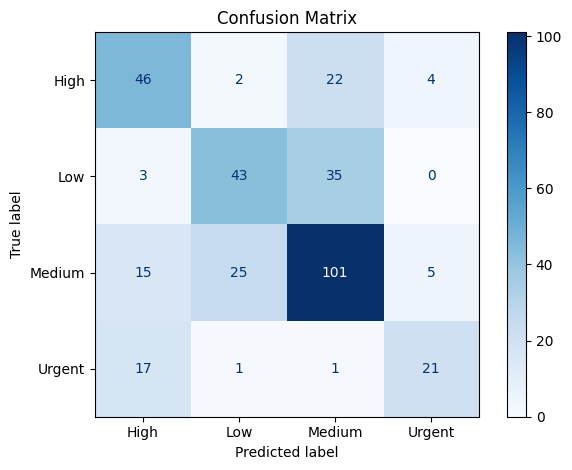

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=['High', 'Low', 'Medium', 'Urgent'],
    cmap="Blues",
    colorbar=True
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
